# Movies Over Time Analysis

This notebook explores how movie characteristics have changed over time.
The analysis focuses on release year and examines trends in:
- average movie ratings
- audience engagement (votes)
- number of released movies per year

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df_movies = pd.read_csv("../data/movies.csv")

In [4]:
df_movies.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [5]:
df_movies["released"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7668 entries, 0 to 7667
Series name: released
Non-Null Count  Dtype 
--------------  ----- 
7666 non-null   object
dtypes: object(1)
memory usage: 60.0+ KB


## Preparing Release Year Data

The `released` column contains both date information and additional text. To enable time-based analysis, the date part was extracted and converted into a proper datetime format.

In [6]:
df_movies["release_date_str"] = df_movies["released"].str.split("(").str[0].str.strip()
df_movies[["released", "release_date_str"]].head()

,released,release_date_str
0,"June 13, 1980 (United States)","June 13, 1980"
1,"July 2, 1980 (United States)","July 2, 1980"
2,"June 20, 1980 (United States)","June 20, 1980"
3,"July 2, 1980 (United States)","July 2, 1980"
4,"July 25, 1980 (United States)","July 25, 1980"


In [7]:
df_movies["release_date"] = pd.to_datetime(df_movies["release_date_str"], errors="coerce")

In [8]:
df_movies["release_year"] = df_movies["release_date"].dt.year

In [9]:
df_movies['release_year'].isna().sum()

np.int64(59)

Due to inconsistent date formats in the `released` column, the release year was extracted using a regular expression rather than relying solely on datetime conversion:

In [10]:
extracted_year = df_movies['released'].str.extract(r'(\d{4})')[0].astype(float)

In [11]:
df_movies['release_year'] = df_movies['release_year'].fillna(extracted_year)

In [12]:
df_movies['release_year'].isna().sum()

np.int64(2)

In [13]:
df_movies = df_movies.dropna(subset=['release_year'])


## Final Data Cleaning

In [14]:
columns = [
    'name',
    'release_year',
    'rating',
    'genre',
    'score',
    'votes'
]
df_movies = df_movies[columns]

In [15]:
df_movies = df_movies.dropna(
    subset=['release_year', 'rating', 'genre', 'score']
)

In [16]:
genre_counts = df_movies['genre'].value_counts()

valid_genres = genre_counts[genre_counts >= 10].index

df_movies = df_movies[df_movies['genre'].isin(valid_genres)]

In [17]:
rating_counts = df_movies['rating'].value_counts()

valid_ratings = rating_counts[rating_counts >= 10].index

df_movies = df_movies[df_movies['rating'].isin(valid_ratings)]

In [18]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7546 entries, 0 to 7659
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          7546 non-null   object 
 1   release_year  7546 non-null   float64
 2   rating        7546 non-null   object 
 3   genre         7546 non-null   object 
 4   score         7546 non-null   float64
 5   votes         7546 non-null   float64
dtypes: float64(3), object(3)
memory usage: 412.7+ KB


## Movies Released Over Time

In [19]:
movies_by_year = df_movies.groupby("release_year")["name"].count()

This section examines how the number of released movies has changed over time. The goal is to identify long-term trends in movie production.

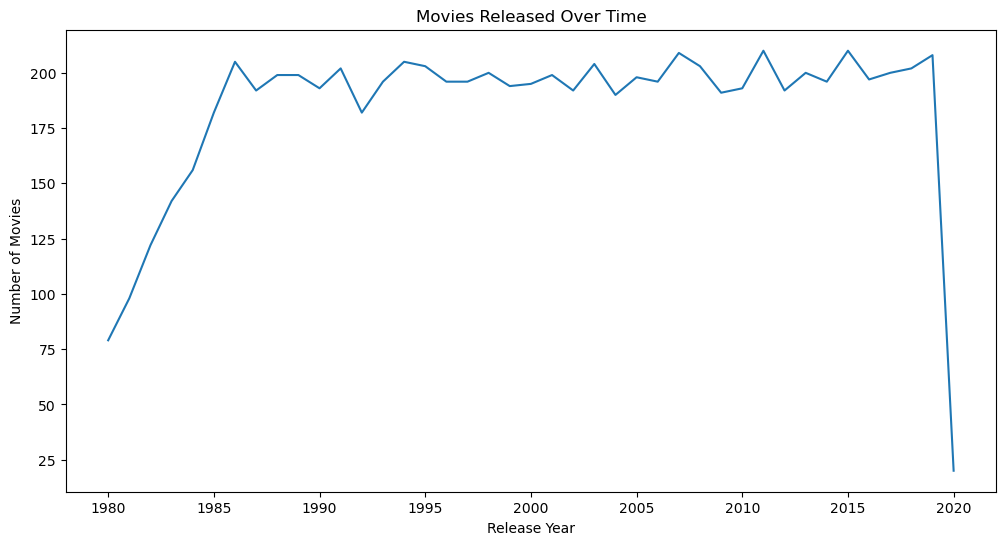

In [20]:
plt.figure(figsize=(12, 6))
movies_by_year.plot(
    xlabel="Release Year",
    ylabel="Number of Movies",
    kind= "line",
    title="Movies Released Over Time"
    )


plt.show()

Overall, movie production shows a long-term increasing trend with a significant disruption in 2020.

A sharp decline in the number of movie releases is observed in 2020. This drop may be influenced by the COVID-19 pandemic, as well as possible incompleteness of the dataset for recent years.

## Average Movie Score Over Time


This section explores how average movie ratings have changed over time. The goal is to understand whether movie quality has improved, declined, or remained stable across different periods.

In [21]:
avr_movie_score_by_year = df_movies.groupby("release_year")["score"].mean().round(2)

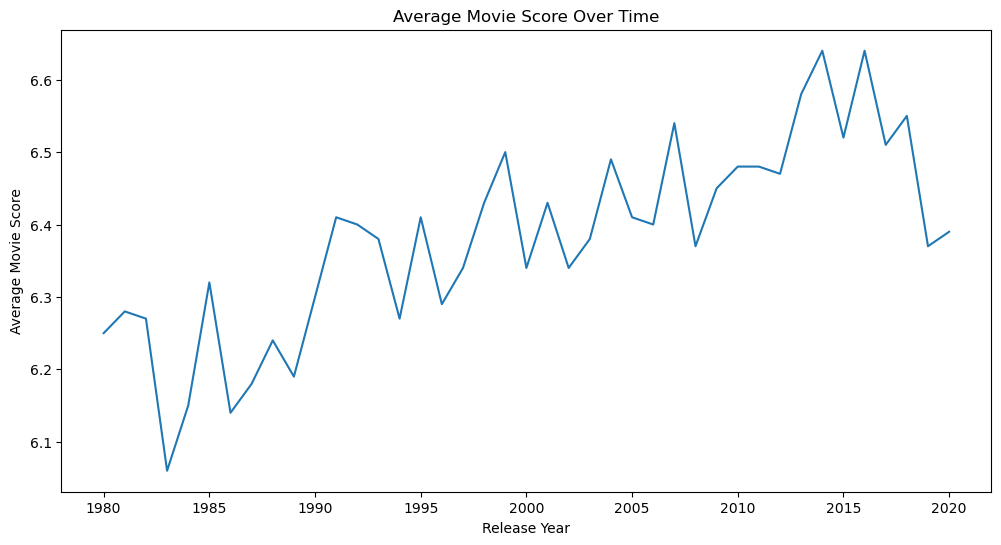

In [22]:
plt.figure(figsize=(12, 6))
avr_movie_score_by_year.plot(
    xlabel="Release Year",
    ylabel="Average Movie Score",
    kind= "line",
    title="Average Movie Score Over Time"
    )


plt.show()

The average movie score shows a relatively stable pattern over time, with only minor fluctuations.
Early years display higher variability, likely due to a smaller number of released movies.
While a slight upward trend is visible in later years, this does not necessarily indicate an improvement in movie quality, but may reflect changes in audience behavior and rating practices.


## Median Movie Score Over Time

In [23]:
median_movie_score_by_year = df_movies.groupby("release_year")["score"].median().round(2)

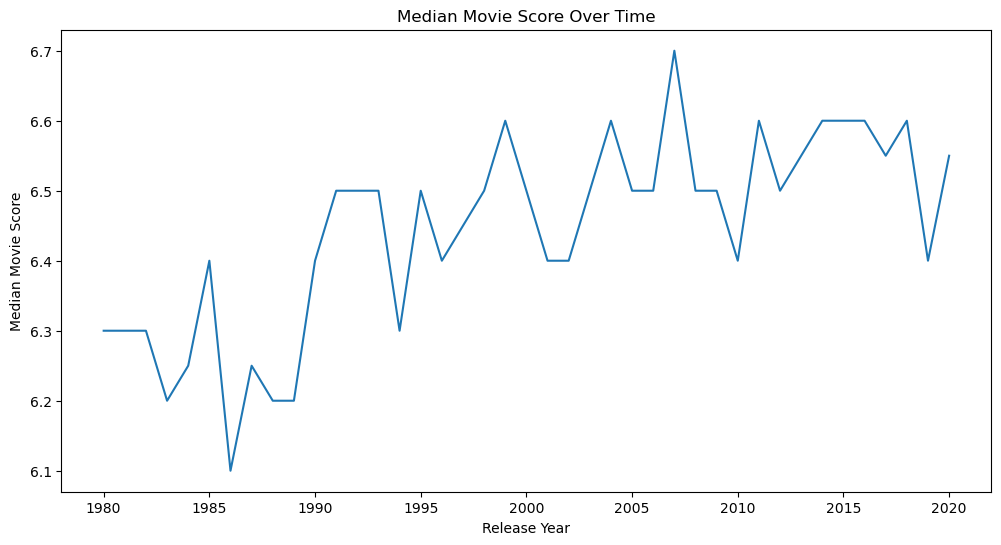

In [24]:
plt.figure(figsize=(12, 6))
median_movie_score_by_year.plot(
    xlabel="Release Year",
    ylabel="Median Movie Score",
    kind= "line",
    title="Median Movie Score Over Time"
    )

plt.show()

## Average VS Median Movie Scores (comparison)

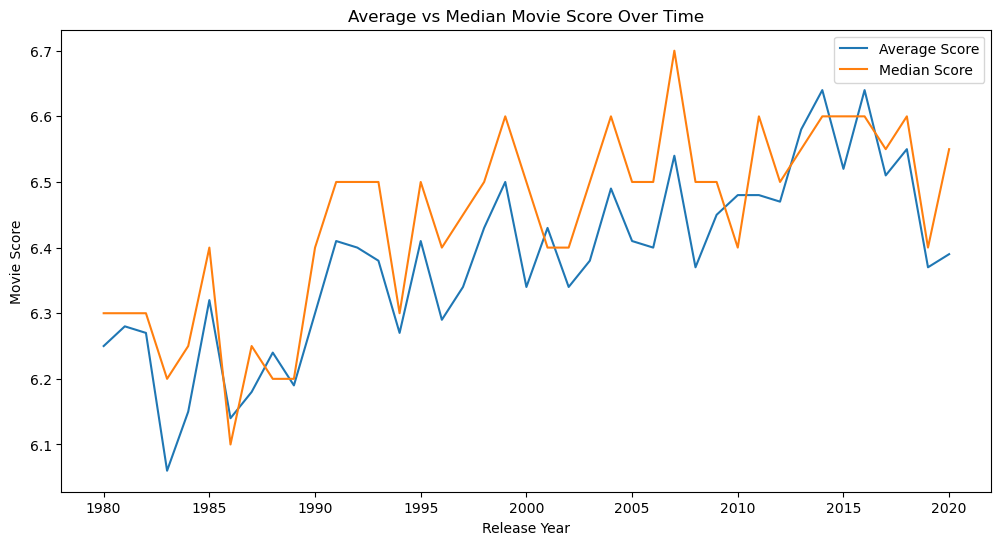

In [25]:
plt.figure(figsize=(12, 6))

avr_movie_score_by_year.plot(
    label="Average Score"
)

median_movie_score_by_year.plot(
    label="Median Score"
)

plt.title("Average vs Median Movie Score Over Time")
plt.xlabel("Release Year")
plt.ylabel("Movie Score")
plt.legend()

plt.show()

The average movie score shows a gradual increase over time, while the median score remains more stable. This suggests that although low-rated movies affect the overall average, the typical movie quality experienced by viewers has not changed as dramatically.

## Writers’ Strike Impact Analysis

The film industry is influenced not only by creative decisions but also by external events.
One such factor is writers’ strikes, which may affect both the quantity and quality of released movies.

In this section, we introduce a dummy variable to indicate whether a movie was released
during a known writers’ strike year and analyze potential patterns in the data.


### Creating a Writers’ Strike Dummy Variable

In [26]:
strike_years = [1988, 2007, 2008, 2023]

In [27]:
df_movies['is_writers_strike'] = df_movies['release_year'].isin(strike_years).astype(int)

In [28]:
df_movies['is_writers_strike'].value_counts()

is_writers_strike
0    6935
1     611
Name: count, dtype: int64

### Average Movie Ratings: Strike vs Non-Strike Years

To assess whether writers’ strikes may have influenced movie quality, we compare average audience ratings for movies released during strike years versus non-strike years.

In [31]:
ratings_during_strike = df_movies.groupby("is_writers_strike")["score"].mean().round(2)
ratings_during_strike

is_writers_strike
0    6.39
1    6.38
Name: score, dtype: float64

The comparison shows almost no difference in average movie ratings between strike and non-strike years.

The dataset likely contains a selection bias, as it includes only released movies, potentially excluding delayed or cancelled projects. As a result, strike periods may influence which movies reach release rather than the ratings of those that do.
